In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [28]:
df = pd.read_csv("../data/processed/EMS_COMPLETE_2024_2025_2026.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [29]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 3629661
Columns : 14


In [30]:
df.head()

,incident_datetime,initial_call_type,final_call_type,first_assignment_datetime,first_activation_datetime,first_on_scene_datetime,first_to_hosp_datetime,incident_close_datetime,dispatch_response_seconds_qy,incident_response_seconds_qy,incident_travel_tm_seconds_qy,zipcode,borough,incident_dispatch_area
0,2024-01-01T00:00:03.000,INJURY,INJURY,2024-01-01T00:00:56.000,2024-01-01T00:01:13.000,2024-01-01T00:06:36.000,NaN,2024-01-01T00:56:41.000,53,393.0,340.0,11365.0,QUEENS,Q5
1,2024-01-01T00:00:14.000,CARD,CARD,2024-01-01T00:01:38.000,2024-01-01T00:01:54.000,2024-01-01T00:07:24.000,2024-01-01T00:26:07.000,2024-01-01T01:19:22.000,84,430.0,346.0,10457.0,BRONX,B2
2,2024-01-01T00:00:18.000,STNDBM,STNDBY,2024-01-01T10:17:05.000,2024-01-01T10:17:05.000,2024-01-01T10:24:18.000,2024-01-01T12:26:21.000,2024-01-01T14:20:21.000,0,NaN,433.0,11224.0,BROOKLYN,K1
3,2024-01-01T00:00:45.000,RESPIR,RESPIR,2024-01-01T00:25:30.000,2024-01-01T00:25:40.000,2024-01-01T00:32:59.000,2024-01-01T00:50:41.000,2024-01-01T01:37:04.000,1485,1934.0,449.0,10033.0,MANHATTAN,M9
4,2024-01-01T00:00:55.000,BURNMI,BURNMI,2024-01-01T00:01:34.000,2024-01-01T00:01:57.000,2024-01-01T00:22:50.000,2024-01-01T01:27:23.000,2024-01-01T02:36:27.000,39,1315.0,1276.0,11208.0,BROOKLYN,K4


In [31]:
df.tail()

,incident_datetime,initial_call_type,final_call_type,first_assignment_datetime,first_activation_datetime,first_on_scene_datetime,first_to_hosp_datetime,incident_close_datetime,dispatch_response_seconds_qy,incident_response_seconds_qy,incident_travel_tm_seconds_qy,zipcode,borough,incident_dispatch_area
3629656,2026-03-31T23:58:45.000,DRUG,DRUG,2026-03-31T23:59:29.000,2026-03-31T23:59:41.000,2026-04-01T00:07:54.000,2026-04-01T00:23:55.000,2026-04-01T01:15:18.000,44,549.0,505.0,11354.0,QUEENS,Q7
3629657,2026-03-31T23:59:04.000,TRAUMA,TRAUMA,2026-03-31T23:59:23.000,2026-03-31T23:59:39.000,2026-04-01T00:07:06.000,NaN,2026-04-01T00:08:54.000,19,482.0,463.0,10458.0,BRONX,B2
3629658,2026-03-31T23:59:45.000,DRUG,DRUG,2026-04-01T00:00:07.000,2026-04-01T00:00:47.000,2026-04-01T00:12:38.000,2026-04-01T01:08:31.000,2026-04-01T02:04:17.000,22,773.0,751.0,11377.0,QUEENS,Q6
3629659,2026-03-31T23:59:49.000,SICK,SICK,2026-04-01T00:00:03.000,2026-04-01T00:00:32.000,2026-04-01T00:03:31.000,NaN,2026-04-01T00:31:19.000,14,222.0,208.0,10309.0,RICHMOND / STATEN ISLAND,S3
3629660,2026-03-31T23:59:57.000,SICK,EDP,2026-04-01T00:00:06.000,2026-04-01T00:00:25.000,2026-04-01T00:12:06.000,2026-04-01T00:29:01.000,2026-04-01T01:20:33.000,9,729.0,720.0,10002.0,MANHATTAN,M1


In [32]:
df.sample(5)

,incident_datetime,initial_call_type,final_call_type,first_assignment_datetime,first_activation_datetime,first_on_scene_datetime,first_to_hosp_datetime,incident_close_datetime,dispatch_response_seconds_qy,incident_response_seconds_qy,incident_travel_tm_seconds_qy,zipcode,borough,incident_dispatch_area
367566,2024-03-25T17:34:34.000,UNC,UNC,2024-03-25T17:35:16.000,2024-03-25T17:35:44.000,2024-03-25T17:47:39.000,NaN,2024-03-25T18:44:06.000,42,785.0,743.0,11226.0,BROOKLYN,K3
1132979,2024-09-10T20:34:24.000,SICK,CVAC,2024-09-10T20:35:26.000,2024-09-10T20:36:05.000,2024-09-10T20:44:19.000,2024-09-10T21:08:43.000,2024-09-10T22:00:20.000,62,595.0,533.0,11225.0,BROOKLYN,K3
962578,2024-08-02T22:04:24.000,DIFFBR,DIFFBR,2024-08-02T22:05:08.000,2024-08-02T22:06:17.000,2024-08-02T22:11:34.000,NaN,2024-08-02T22:17:58.000,44,430.0,386.0,10468.0,BRONX,B5
3401004,2026-02-06T17:05:19.000,UNKNOW,UNKNOW,2026-02-06T17:29:03.000,2026-02-06T17:31:03.000,2026-02-06T18:19:08.000,NaN,2026-02-06T18:23:14.000,1424,4429.0,3005.0,11212.0,BROOKLYN,K4
2045780,2025-04-06T20:30:18.000,RESPIR,DIFFBR,2025-04-06T20:38:50.000,2025-04-06T20:39:05.000,2025-04-06T20:44:10.000,NaN,2025-04-06T21:28:34.000,512,832.0,320.0,11423.0,QUEENS,Q2


In [33]:
df.columns.tolist()

['incident_datetime',
 'initial_call_type',
 'final_call_type',
 'first_assignment_datetime',
 'first_activation_datetime',
 'first_on_scene_datetime',
 'first_to_hosp_datetime',
 'incident_close_datetime',
 'dispatch_response_seconds_qy',
 'incident_response_seconds_qy',
 'incident_travel_tm_seconds_qy',
 'zipcode',
 'borough',
 'incident_dispatch_area']

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3629661 entries, 0 to 3629660
Data columns (total 14 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   incident_datetime              str    
 1   initial_call_type              str    
 2   final_call_type                str    
 3   first_assignment_datetime      str    
 4   first_activation_datetime      str    
 5   first_on_scene_datetime        str    
 6   first_to_hosp_datetime         str    
 7   incident_close_datetime        str    
 8   dispatch_response_seconds_qy   int64  
 9   incident_response_seconds_qy   float64
 10  incident_travel_tm_seconds_qy  float64
 11  zipcode                        float64
 12  borough                        str    
 13  incident_dispatch_area         str    
dtypes: float64(3), int64(1), str(10)
memory usage: 387.7 MB


In [35]:
df.dtypes

incident_datetime                    str
initial_call_type                    str
final_call_type                      str
first_assignment_datetime            str
first_activation_datetime            str
first_on_scene_datetime              str
first_to_hosp_datetime               str
incident_close_datetime              str
dispatch_response_seconds_qy       int64
incident_response_seconds_qy     float64
incident_travel_tm_seconds_qy    float64
zipcode                          float64
borough                              str
incident_dispatch_area               str
dtype: object

In [36]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
first_to_hosp_datetime,1416371,39.022129
incident_response_seconds_qy,222064,6.118037
incident_travel_tm_seconds_qy,221185,6.093820
first_on_scene_datetime,221126,6.092194
first_activation_datetime,84687,2.333193
first_assignment_datetime,77419,2.132954
zipcode,42641,1.174793
incident_close_datetime,480,0.013224
incident_datetime,0,0.000000
initial_call_type,0,0.000000


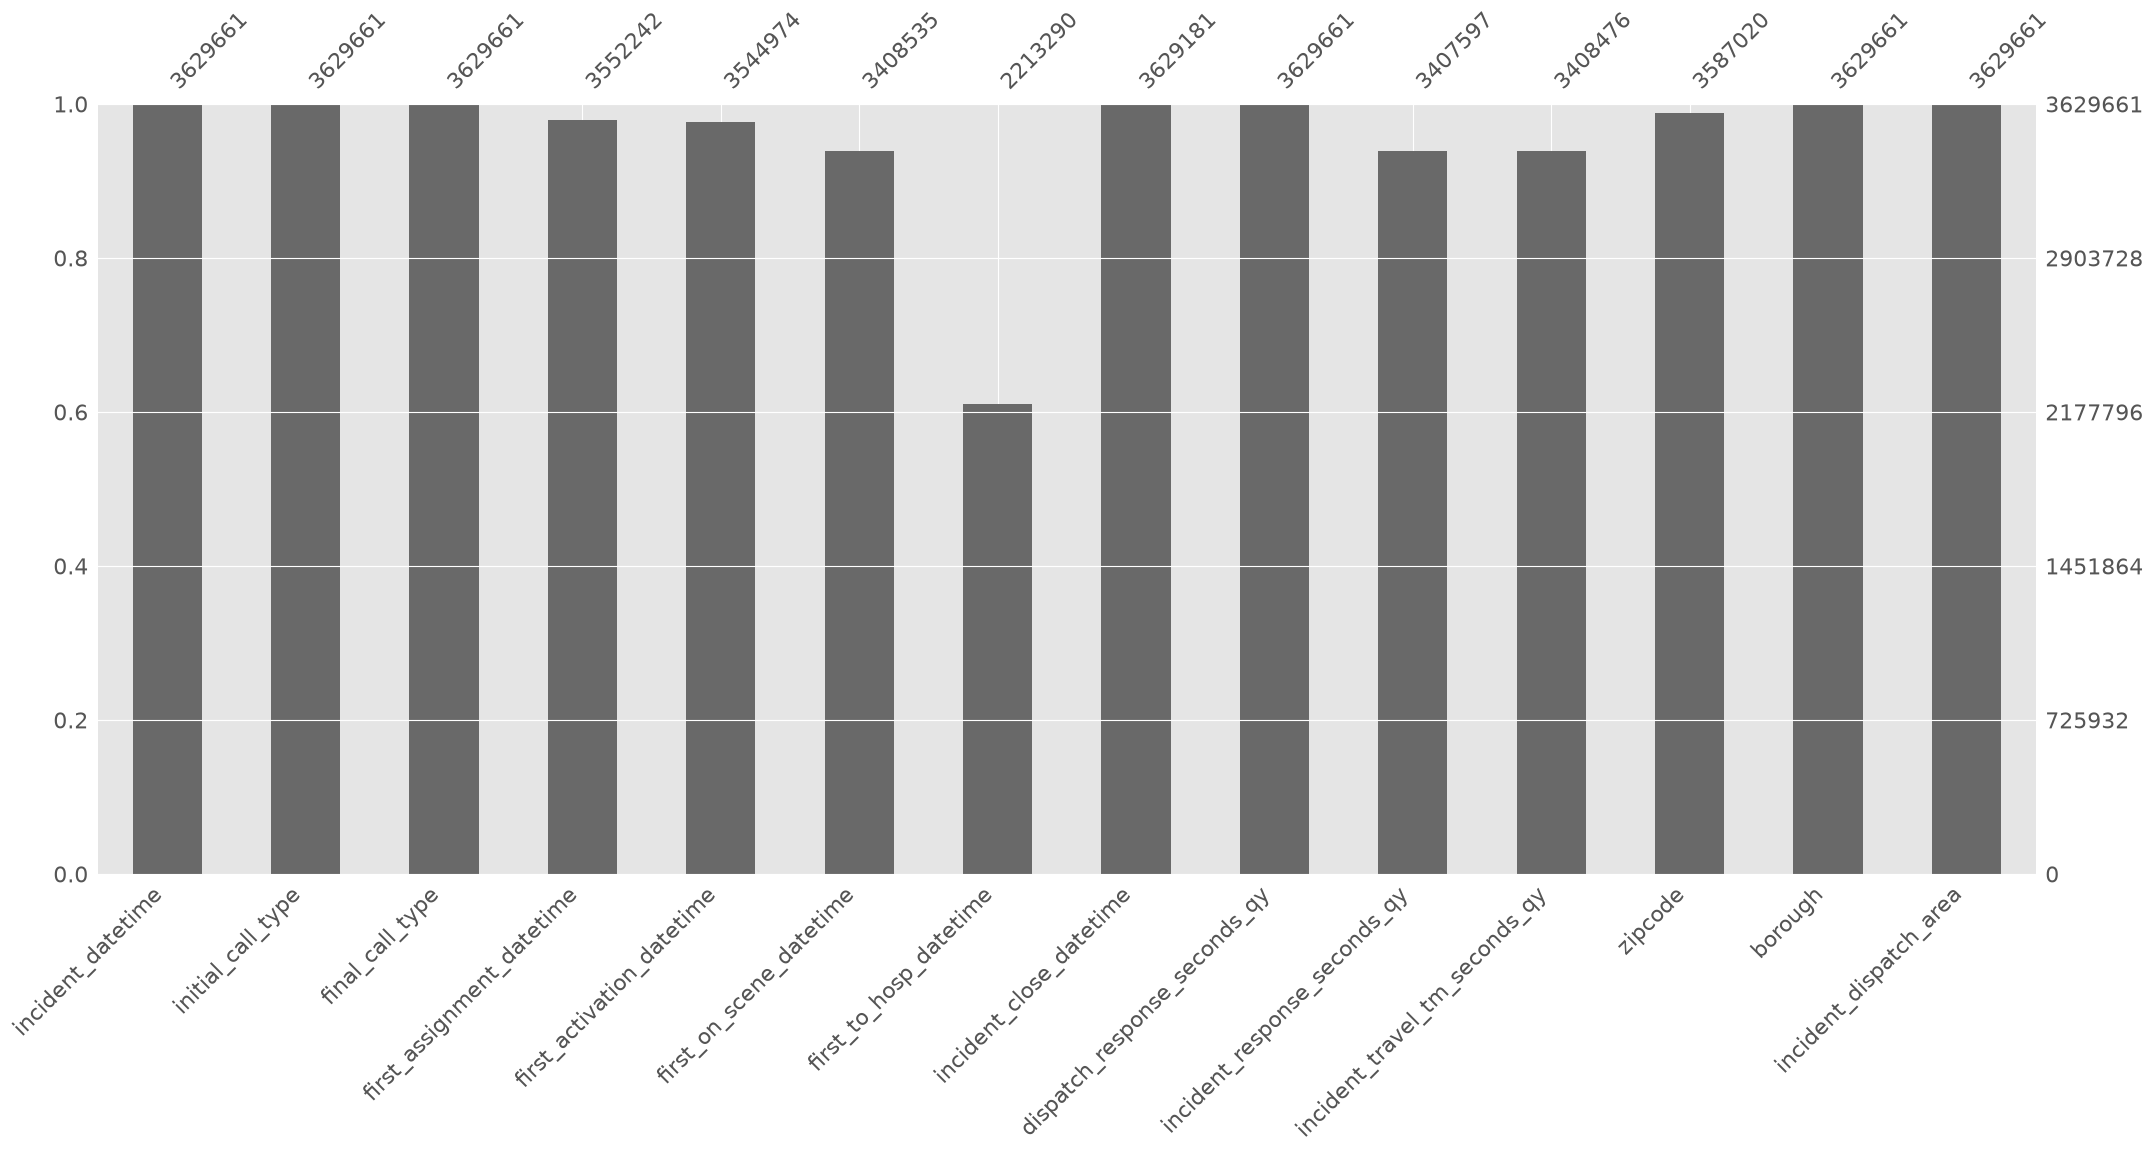

In [37]:
plt.figure(figsize=(14,6))

msno.bar(df)

plt.show()

In [38]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
dispatch_response_seconds_qy,3629661.0,304.897058,1207.943864,0.0,13.0,29.0,85.0,32390.0
incident_response_seconds_qy,3407597.0,936.633032,1440.538264,0.0,377.0,564.0,917.0,32396.0
incident_travel_tm_seconds_qy,3408476.0,639.201429,685.320051,0.0,330.0,489.0,735.0,90337.0
zipcode,3587020.0,10744.901686,549.084857,83.0,10302.0,10472.0,11228.0,12345.0


In [40]:
df.describe(include="object").T

,count,unique,top,freq
incident_datetime,3629661,3534454,2024-09-04T15:25:19.000,5
initial_call_type,3629661,131,INJURY,437223
final_call_type,3629661,143,SICK,435316
first_assignment_datetime,3552242,3464506,2024-03-06T10:18:10.000,4
first_activation_datetime,3544974,3449917,2024-02-05T18:40:20.000,4
first_on_scene_datetime,3408535,3321370,2024-06-05T21:27:38.000,5
first_to_hosp_datetime,2213290,2206074,2024-04-05T20:03:50.000,4
incident_close_datetime,3629181,3526288,2024-12-10T02:00:00.000,11
borough,3629661,6,BROOKLYN,1002290
incident_dispatch_area,3629661,34,B2,253459


In [41]:
unique = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

unique

,Column,Unique Values
0,incident_datetime,3534454
1,initial_call_type,131
2,final_call_type,143
3,first_assignment_datetime,3464506
4,first_activation_datetime,3449917
5,first_on_scene_datetime,3321370
6,first_to_hosp_datetime,2206074
7,incident_close_datetime,3526288
8,dispatch_response_seconds_qy,16933
9,incident_response_seconds_qy,18578


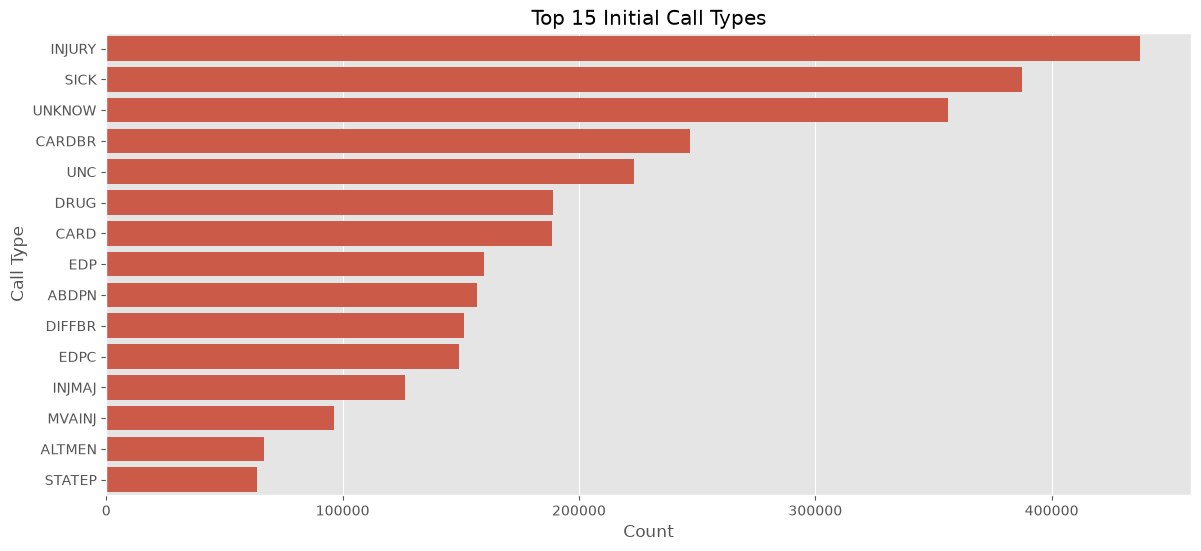

In [42]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    y="initial_call_type",
    order=df["initial_call_type"].value_counts().head(15).index
)

plt.title("Top 15 Initial Call Types")
plt.xlabel("Count")
plt.ylabel("Call Type")

plt.show()

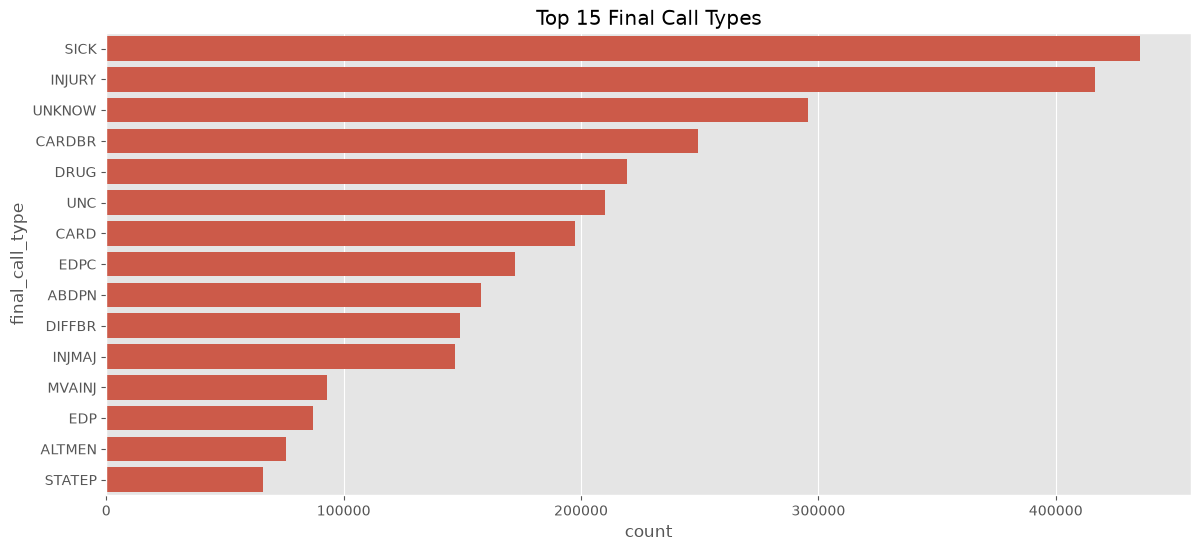

In [43]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    y="final_call_type",
    order=df["final_call_type"].value_counts().head(15).index
)

plt.title("Top 15 Final Call Types")

plt.show()

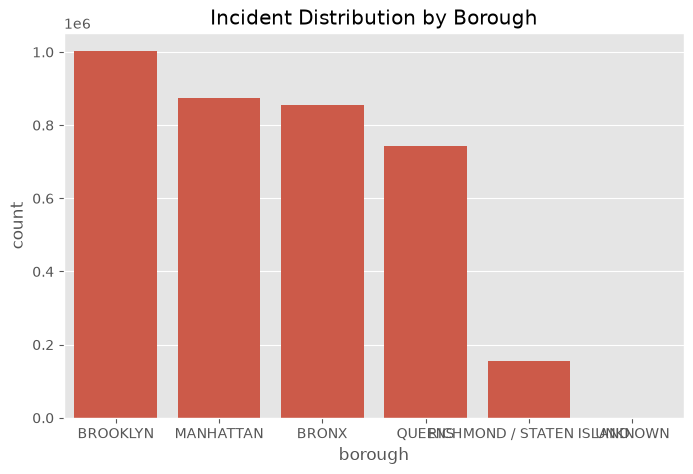

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="borough",
    order=df["borough"].value_counts().index
)

plt.title("Incident Distribution by Borough")

plt.show()

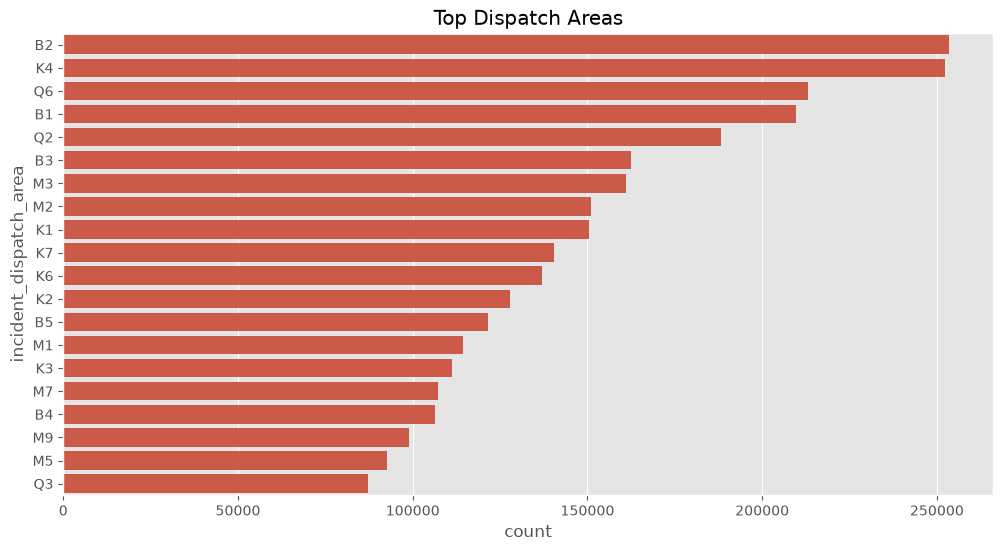

In [45]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="incident_dispatch_area",
    order=df["incident_dispatch_area"].value_counts().head(20).index
)

plt.title("Top Dispatch Areas")

plt.show()

In [46]:
df["incident_datetime"] = pd.to_datetime(df["incident_datetime"])

In [47]:
df["hour"] = df["incident_datetime"].dt.hour

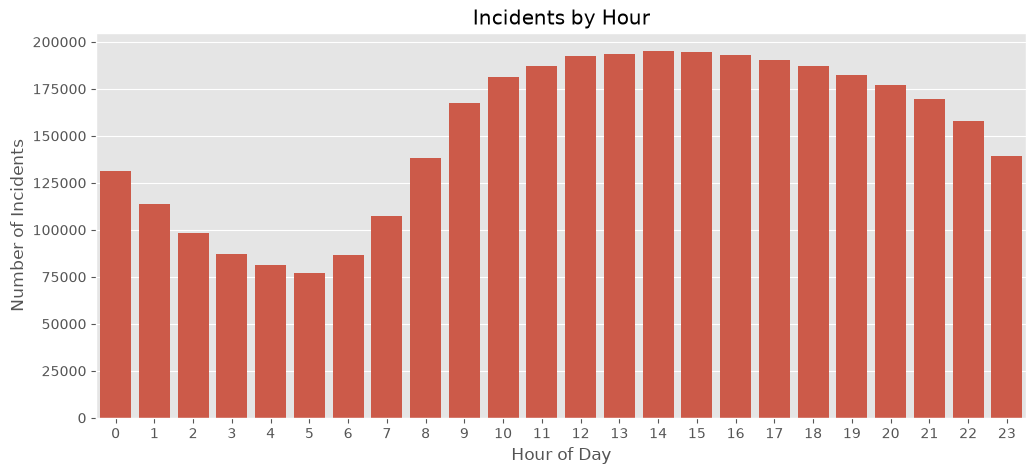

In [48]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="hour",
    order=sorted(df["hour"].unique())
)

plt.title("Incidents by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Incidents")

plt.show()

In [49]:
df["incident_datetime"] = pd.to_datetime(df["incident_datetime"], errors="coerce")

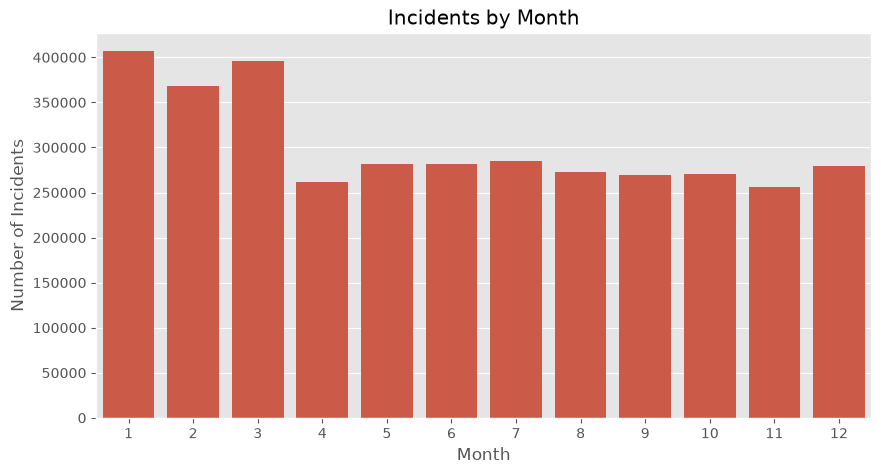

In [50]:
df["month"] = df["incident_datetime"].dt.month

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="month",
    order=range(1, 13)
)

plt.title("Incidents by Month")
plt.xlabel("Month")
plt.ylabel("Number of Incidents")

plt.show()

In [55]:
df["incident_datetime"] = pd.to_datetime(df["incident_datetime"])

df["weekday"] = df["incident_datetime"].dt.day_name()

In [56]:
print(df[["incident_datetime", "weekday"]].head())

    incident_datetime weekday
0 2024-01-01 00:00:03  Monday
1 2024-01-01 00:00:14  Monday
2 2024-01-01 00:00:18  Monday
3 2024-01-01 00:00:45  Monday
4 2024-01-01 00:00:55  Monday


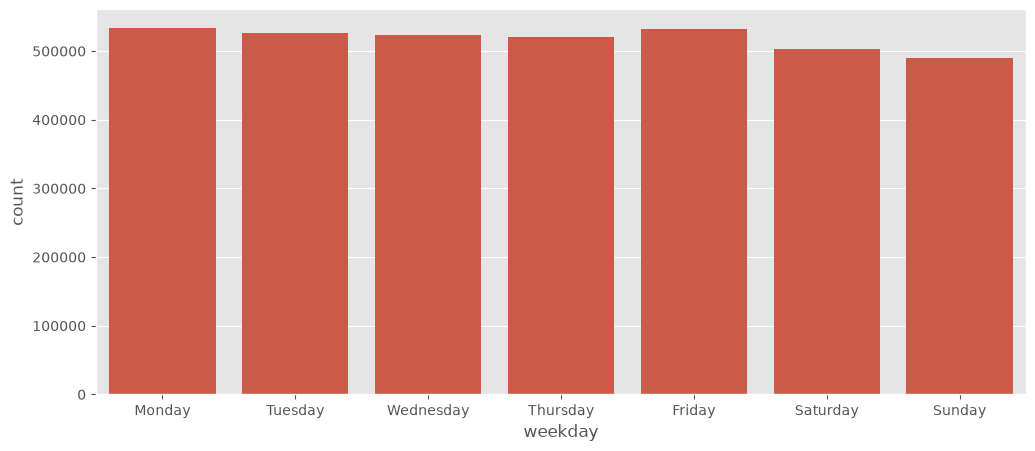

In [57]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="weekday",
    order=weekday_order
)

plt.show()

In [59]:
df["Weekend"] = df["weekday"].isin(["Saturday", "Sunday"])

In [60]:
df["Weekend"] = df["weekday"].isin(["Saturday", "Sunday"]).map({
    True: "Weekend",
    False: "Weekday"
})

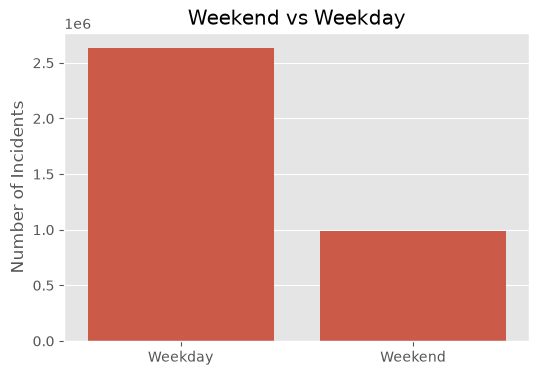

In [61]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Weekend",
    order=["Weekday", "Weekend"]   # optional, fixed order
)

plt.title("Weekend vs Weekday")
plt.xlabel("")
plt.ylabel("Number of Incidents")

plt.show()

In [63]:
print(df.columns)

Index(['incident_datetime', 'initial_call_type', 'final_call_type',
       'first_assignment_datetime', 'first_activation_datetime',
       'first_on_scene_datetime', 'first_to_hosp_datetime',
       'incident_close_datetime', 'dispatch_response_seconds_qy',
       'incident_response_seconds_qy', 'incident_travel_tm_seconds_qy',
       'zipcode', 'borough', 'incident_dispatch_area', 'hour', 'month',
       'weekday', 'Weekend'],
      dtype='str')


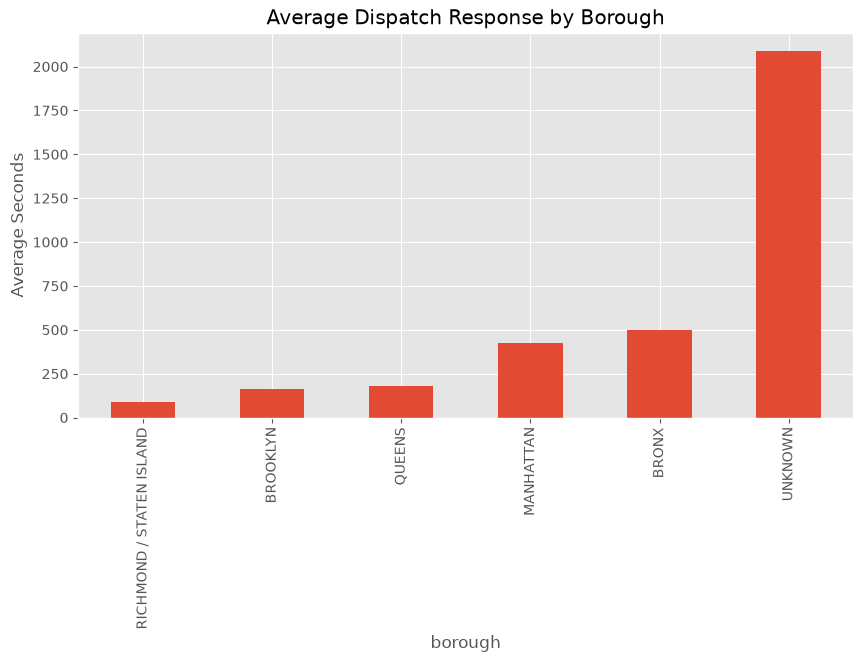

In [65]:
borough_response = df.groupby("borough")["dispatch_response_seconds_qy"].mean().sort_values()

plt.figure(figsize=(10,5))

borough_response.plot(kind="bar")

plt.ylabel("Average Seconds")

plt.title("Average Dispatch Response by Borough")

plt.show()

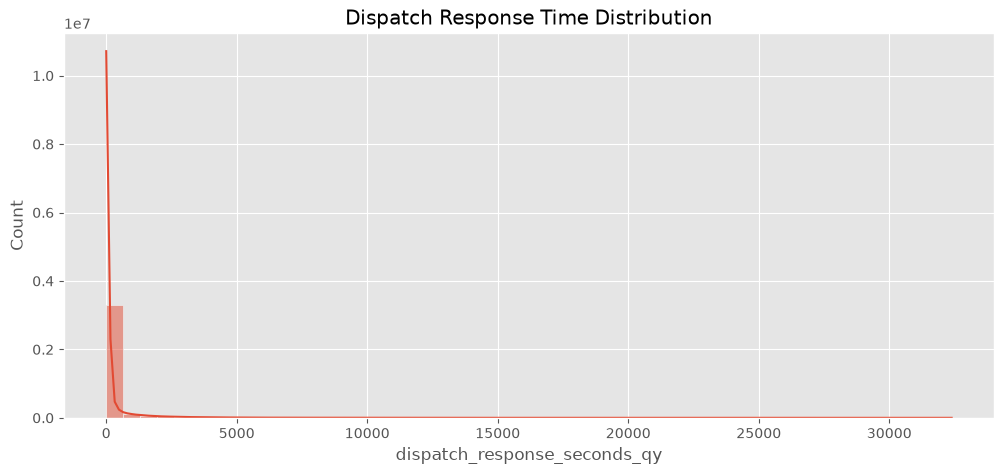

In [67]:
plt.figure(figsize=(12,5))

sns.histplot(
    df["dispatch_response_seconds_qy"],
    bins=50,
    kde=True
)

plt.title("Dispatch Response Time Distribution")

plt.show()

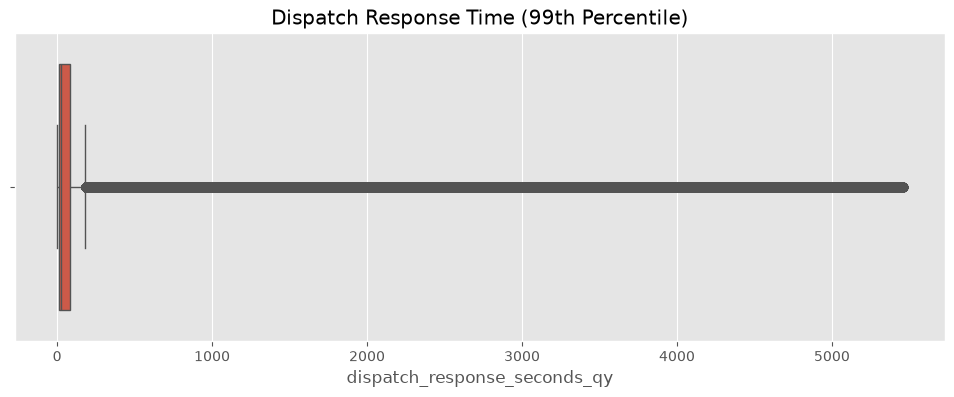

In [68]:
limit = df["dispatch_response_seconds_qy"].quantile(0.99)

plt.figure(figsize=(12,4))

sns.boxplot(
    x=df[df["dispatch_response_seconds_qy"] <= limit]["dispatch_response_seconds_qy"]
)

plt.title("Dispatch Response Time (99th Percentile)")

plt.show()

In [69]:
df["dispatch_response_seconds_qy"].describe()

count    3.629661e+06
mean     3.048971e+02
std      1.207944e+03
min      0.000000e+00
25%      1.300000e+01
50%      2.900000e+01
75%      8.500000e+01
max      3.239000e+04
Name: dispatch_response_seconds_qy, dtype: float64

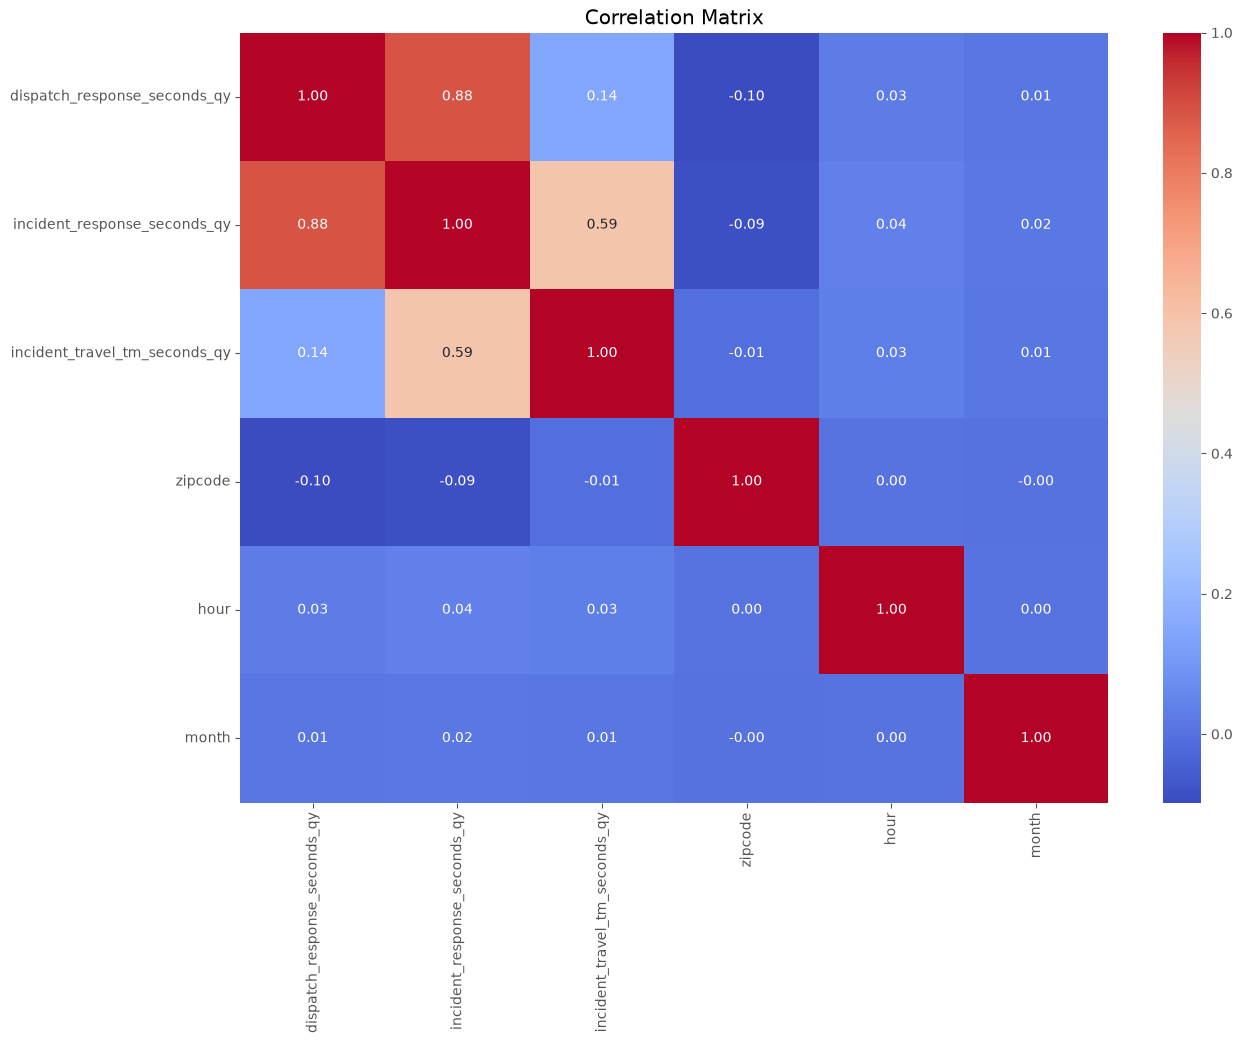

In [70]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [71]:
Q1 = df["dispatch_response_seconds_qy"].quantile(0.25)
Q3 = df["dispatch_response_seconds_qy"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["dispatch_response_seconds_qy"] < lower) |
    (df["dispatch_response_seconds_qy"] > upper)
]

print("Number of Outliers:", len(outliers))

print(
    "Percentage:",
    round(len(outliers)/len(df)*100,2),
    "%"
)

Number of Outliers: 578630
Percentage: 15.94 %


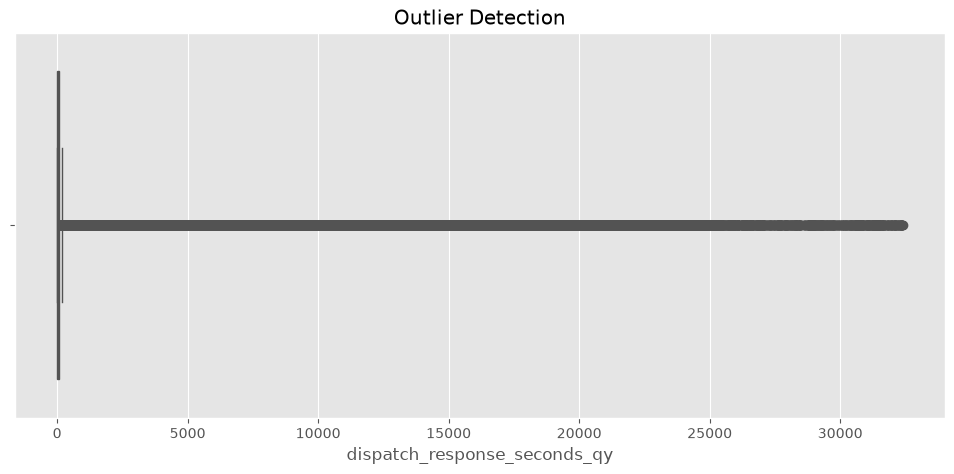

In [72]:
plt.figure(figsize=(12,5))

sns.boxplot(
    x=df["dispatch_response_seconds_qy"]
)

plt.title("Outlier Detection")

plt.show()

In [75]:
df["Year"] = df["incident_datetime"].dt.year
df["Month"] = df["incident_datetime"].dt.month
df["Day"] = df["incident_datetime"].dt.day
df["Hour"] = df["incident_datetime"].dt.hour
df["Weekday"] = df["incident_datetime"].dt.day_name()
df["Weekend"] = df["weekday"].isin(
    ["Saturday","Sunday"]
)

In [77]:
df["incident_datetime"] = pd.to_datetime(df["incident_datetime"])
df["incident_close_datetime"] = pd.to_datetime(df["incident_close_datetime"])

df["incident_duration"] = (
    df["incident_close_datetime"] - df["incident_datetime"]
).dt.total_seconds()

In [78]:
df["first_assignment_datetime"] = pd.to_datetime(df["first_assignment_datetime"])
df["incident_datetime"] = pd.to_datetime(df["incident_datetime"])

df["dispatch_delay"] = (
    df["first_assignment_datetime"] -
    df["incident_datetime"]
).dt.total_seconds()

In [79]:
df.to_csv(
    "../data/processed/eda_ready_dataset.csv",
    index=False
)

print("EDA dataset saved successfully.")

EDA dataset saved successfully.
